In [104]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

%load_ext autoreload 
%autoreload 2
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:

from systematic_plots import load_ocp_paths, adding_maps, load_homepath, calculate_objects, load_photolyase_paths
from systematic_plots import cut_resolution, calculate_scaled_maps
import reciprocalspaceship as rs
info_container=load_ocp_paths()[0]
evaluation_path = load_homepath() + "../evaluation/"

# info_containers=load_photolyase_paths()
# for info_container in info_containers:
#     if info_container['fshort'] == "PL30ns" and info_container['datatype'] == "photolyase":
#         break
# print(rs.read_mtz(info_container["dataloc_dark"]).compute_dHKL()).min()

dataloc_dark = info_container["dataloc_dark"]
dataloc_light = info_container["dataloc_light"]

hs_limit = info_container["hs_limit"]
map_sampling = info_container["map_sampling"]

ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

# ds_dark = cut_resolution(ds_dark, high_resolution_limit=hs_limit)
# ds_light = cut_resolution(ds_light, high_resolution_limit=hs_limit)

map_dark, map_light = calculate_scaled_maps(ds_dark, ds_light, info_container)

In [112]:

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map, compute_kweighted_difference_map

diffmap_vanilla = compute_difference_map(map_light, map_dark)
diffmap_kweighted, kweighted_meta = max_negentropy_kweighted_difference_map(map_light, map_dark, )


[158.12284918807654, 154.95619305333184, 136.49533221803813, 135.35019600816304, 140.85603463469306, 146.17061722351445, 147.58891310066338, 150.98974354477832, 135.83890762484225, 134.2646442168416, 125.85157850772157, 121.45653218397001, 120.98567051399095, 119.31568647758104, 116.13089137848965, 113.70784901840034, 97.70766763234951, 93.97733873740071, 96.59916449805314, 93.25977768985103, 91.86533357040025, 92.07588956107884, 78.22827698928086, 73.73221057490446, 72.28014211252685, 69.35731655403288, 68.90414096913082, 70.59731312864551, 70.59731312864551, 73.64661167447048, 73.32228577003116, 68.7456368898429, 70.81763342540944, 74.27899832000548, 66.22534453781918, 69.40529633438928, 66.64182641549269, 59.2944912425819, 56.66537630814878, 55.11930584362403, 51.186727074948294, 51.186727074948294, 51.186727074948294, 52.37001406866716, 52.13689405860373, 52.323763749576756, 52.323763749576756, 52.323763749576756, 52.323763749576756, 52.323763749576756, 52.323763749576756, 52.32376

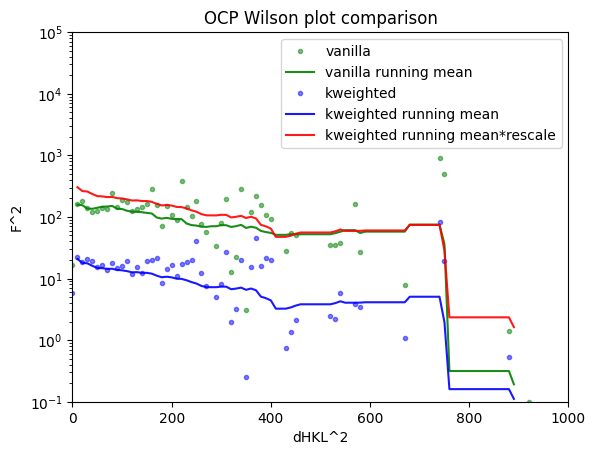

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import reciprocalspaceship as rs
import pandas as pd
plt.figure()
ds_vanilla = rs.DataSet(diffmap_vanilla)
ds_kweighted = rs.DataSet(diffmap_kweighted)
ds_vanilla.compute_dHKL(inplace=True)
ds_kweighted.compute_dHKL(inplace=True)
# for dDHkl bins of length 5 
for ds, name, color in [(ds_vanilla, 'vanilla', "green"), (ds_kweighted, 'kweighted', "blue")]:
    ds["dHKL_bin"] = (ds.dHKL**2 // 10) *10 
    ds_mean = ds.groupby("dHKL_bin").mean().reset_index()
    plt.plot(ds_mean.dHKL_bin, ds_mean.F**2, ".", label=name, alpha=0.5, color=color)
# for ds, name in [(ds_vanilla, 'vanilla'), (ds_kweighted, 'kweighted')]:
    dmaxs = np.arange(10, 900, 10)
    F_means = []
    for dmax in dmaxs:
        mask = (ds.dHKL**2 >dmax) 
        F_mean = np.mean(ds.loc[mask, "F"])
        F_means.append(F_mean**2)
    print(F_means)
    plt.plot(dmaxs, F_means, "-", label=name+" running mean", alpha=0.9, color=color)
    if name == "kweighted":
        plt.plot(dmaxs, np.array(F_means)*3.826207399368286**2, "-", label=name+" running mean*rescale", alpha=0.9, color="red")
plt.xlabel("dHKL^2")
plt.ylabel("F^2")
make_log = False
if make_log:
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim(3,10_000)
    # plt.ylim(1,10_000)
    # plt.xlim(0,1000)
else: 
    plt.yscale("log")
    plt.xlim(0,1000)
    plt.ylim(1e-1,1e5)
plt.legend()
plt.title(info_container['fshort'] + " Wilson plot comparison")
plt.show()

In [114]:
from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map, compute_kweighted_difference_map
import reciprocalspaceship as rs
import numpy as np


xtr_factor = 3.76
from meteor import rsmap
from meteorize import saving_xtrapolated_map, rescaling_diffmap, adding_maps
import logging
logger = logging.getLogger(__name__)
%load_ext autoreload
%autoreload 2
seed_dataset = rs.read_mtz(info_container["dataloc_dark"])
filename = "xtr_kmap_"+info_container['fshort']
def saving_xtrapolated_map(
        diffmap:rsmap.Map, 
        *,
        map_dark:rsmap.Map, 
        xtr_factor:float,
        reference_diffmap:rsmap.Map = None,
        seed_dataset:rs.DataSet = None,
        save_diffmap:bool = False,
        filename : str = "xtr_map"
        ):
    diffmap =rescaling_diffmap(diffmap.copy(), reference_diffmap) 
    xtr_map = adding_maps(map_dark, diffmap, factor2=xtr_factor)
    # xtr_map.uncertainties *= 10000
    if seed_dataset is not None:
        implant = rs.DataSet(seed_dataset.copy())
        implant[["F", "SIGF", "PHIC"]] = xtr_map[["F", "SIGF", "PHI"]]
        necessary_cols = ["H", "K", "L", "F", "SIGF", "PHIC", "FreeR_flag"]
        implant = implant.drop(columns=[col for col in implant.columns if col not in necessary_cols])
    mask = np.logical_or((~implant["F"].isna() & implant["SIGF"].isna()), (implant["F"].isna() & ~implant["SIGF"].isna()))
    non_matching_indices = np.sum(np.array(mask))
    if non_matching_indices > 0:
        print(non_matching_indices)
        logger.warning(f"Number of rows with not shared NaNs in F and SIGF: {non_matching_indices}")
    implant.loc[mask, ["F", "PHIC"]] = np.nan
    implant.write_mtz(f"{filename}_{xtr_factor}.mtz")
    print(f"Written {filename}_{xtr_factor}.mtz")
    if save_diffmap:
        diffmap.write_mtz(f"diffmap_kweighted.mtz")
        return xtr_map, diffmap
    return implant

xtr_kmap, _ = saving_xtrapolated_map(
    diffmap_kweighted, 
    map_dark=map_dark, 
    xtr_factor=xtr_factor, 
    reference_diffmap=diffmap_vanilla, 
    seed_dataset=seed_dataset,
    save_diffmap=True,
    filename=filename
)
xtr_kmap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-08-29 17:14:38,839: meteorize: INFO: Rescaled map by factor 3.8862223625183105 (meteorize.py:808)


Written xtr_kmap_OCP_3.76.mtz


F         PHI       SIGF
H  K L                                    
0  0 3     4.871281    0.000019  46.061832
     6   697.358521  179.999985   30.25457
     9   615.778687 -179.999954  30.213118
     12   408.86557         0.0  32.261818
     15  272.645905         0.0    35.4501
...             ...         ...        ...
43 0 3    21.159124         0.0  47.465454
     4     1.135608  119.999855  47.561893
     5    12.301913 -119.999939  46.990231
     6    24.285456      -180.0  47.549644
     7     4.009449  -60.000038  47.162865

[42732 rows x 3 columns]

In [115]:
def new_diffmap(diffmap, reference_diffmap, map_dark, xtr_factor):
    diffmap =rescaling_diffmap(diffmap.copy(), reference_diffmap) 
    xtr_map = adding_maps(map_dark, diffmap, factor2=xtr_factor)
    new_diffmap = adding_maps(map_dark, xtr_map, factor1=-1)
    print(np.mean(new_diffmap["F"] - diffmap["F"]))
    print(np.mean(new_diffmap["F"] - reference_diffmap["F"]))
    new_diffmap["F"] = reference_diffmap["F"]
    return new_diffmap
diffmap_new = new_diffmap(diffmap_kweighted, diffmap_vanilla, map_dark, xtr_factor)



2025-08-29 17:14:39,493: meteorize: INFO: Rescaled map by factor 3.8862223625183105 (meteorize.py:808)


29.3179
34.602455


In [96]:
rs.read_mtz(filename+"_3.76.mtz")
# rs.read_mtz("~/Downloads/xtr_kmap_7.8.mtz")
# ! ls ~/Downloads

F        SIGF   PHIC
H  K  L                                 
0  0  6   3373.088135  188.562912   -0.0
      8    137.189056  169.399994 -180.0
      10   628.837341  170.245468    0.0
      12  1292.550049  139.947433 -180.0
      14   364.019501   170.62883 -180.0
...               ...         ...    ...
57 14 5           NaN         NaN    NaN
      6           NaN         NaN    NaN
0  0  2           NaN         NaN    NaN
   1  1           NaN         NaN    NaN
      2           NaN         NaN    NaN

[418451 rows x 3 columns]

In [116]:
from meteor.tv import tv_denoise_difference_map

diffmap_tv = tv_denoise_difference_map(diffmap_kweighted)



In [118]:

xtr_factor = 9.9
seed_dataset = rs.read_mtz(info_container["dataloc_dark"])
filename = "xtr_tvmap_"+info_container['fshort']

xtr_tvmap, _ = saving_xtrapolated_map(
    diffmap_tv, 
    map_dark=map_dark, 
    xtr_factor=xtr_factor, 
    reference_diffmap=diffmap_vanilla, 
    seed_dataset=seed_dataset,
    save_diffmap=True,
    filename=filename
)
xtr_tvmap

2025-08-29 17:16:28,100: meteorize: INFO: Rescaled map by factor 6.067244052886963 (meteorize.py:808)
2025-08-29 17:16:28,135: __main__: WARNING: Number of rows with not shared NaNs in F and SIGF: 23 (1707599967.py:37)


23
Written xtr_tvmap_OCP_9.9.mtz


F         PHI        SIGF
H  K L                                     
0  0 3    37.255459    6.004599   188.71196
     6   820.222778 -179.766586  107.713425
     9   619.201843  178.394714  103.899307
     12  389.738403    1.651602  118.716812
     15  365.859558   -0.331056  141.056747
...             ...         ...         ...
43 0 3    20.169724   -1.689089  194.514404
     4    11.167963  -26.586063  194.617249
     5     7.809098 -106.492523  192.614044
     6     5.553694   12.377007  194.314163
     7    17.229673  -60.472256   193.06636

[42732 rows x 3 columns]